### WS 2020/21 <span style="float: right;">GET Lab<br />Paderborn University</span><br />
## <center>Digital Image Processing I<br /><br />Task Sheet 14</center>
---

### Overview

The objective of this exercise is to study image compression methods. In principal, it can be distinguished between losless and lossy compression. Furthermore, it can be distinguished between coding redundancy, interpixel redundancy, and psychovisual redundancy. This task sheet focuses on losless compression using interpixel redundancy.

To evaluate a compression, the compression ratio $C_R$ and the relative data redundancy $R_D$ can be used. If $n_1$ and $n_2$ are the number of information-carrying units (bits or bytes), they can be computed as follows:

$$C_R = \dfrac{n_1}{n_2}$$

$$R_D = 1-\dfrac{1}{C_R}$$

The following figure shows a simplified system structure which obtains a *losless* compression $f_c(x,y)$ for a given image $f(x,y)$, and the reconstruction of the original image:
<br />
<center><img src="images/simple-compression.png"  width="600px" /></center>
<br />

Note that the mapper transforms the input data into a (usually non-visual) format to reduce interpixel redundancies. When these information are transferred to a channel (a harddisk, internet connection, etc.), it is common to add a quantizer and a symbol encoder for more efficient coding (e.g. variable length coding), which are then additional components of the (source) encoder / decoder.

---

In [2]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from tqdm import tqdm

dpi = plt.rcParams['figure.dpi']

# plot image in original size
def plot_img_orig(img):
    fig = plt.figure(figsize = (img.shape[1]/dpi, img.shape[0]/dpi))
    fig.add_axes([0, 0, 1, 1])
    plt.axis('off')
    plt.imshow(img, cmap='gray', vmin=0, vmax=255) # cmap parameter is ignored for RGB(A) data
    plt.show()

#### <span style="color: RoyalBlue; font-weight: bold;">Task 14.1</span> Run-Length Encoding (RLE)

Run-length encoding (also referred to as run-length coding, RLC) is a simple method for lossless data compression. The method uses interpixel redundancies by representing each pixel *run* (a sequence with the same intensity) as a pair of the intensity and the number of pixels in the sequence (e.g., [<span style="color: blue;">1, 1, 1,</span> <span style="color: red;">2, 2, 2, 2, 2</span>] → [<span style="color: blue;">1, 3,</span> <span style="color: red;">2, 5</span>] ). Along with specific extensions, it is also used for facsimile (FAX) compression. If there are only short pixel runs, there is no compression or even extension.

In this exercise, the images can be flattend using <a href="https://numpy.org/doc/stable/reference/generated/numpy.ndarray.flatten.html">`flatten` ↗ </a> from Numpy to obtain a 1D representation. The RLE representation can then be computed in a 1D manner. The Numpy function <a href="https://numpy.org/doc/stable/reference/generated/numpy.append.html">`append` ↗</a> can be used to append values to an existing array (empty arrays are already provided for convenience).

Implement / solve the following tasks:
    
1. Implement an 8 bit (`dtype=np.uint8`) based RLE encoder which works in a 1D manner as described above. 
2. Compute the compression ratio and relative data redundancy for the following test images: *stripes.png*, *stripes-vertical.png*, *lena-250x250.png*, *upb-logo.png*.
3. Implement the corresponding RLE decoder and test it by plotting the decoded images (<span style="color: RoyalBlue; font-weight: bold;">*</span>).

For the development of your functions, the test image *stripes.png* is particularly helpful, because it contains lines of constant intensities so that it is more easy to check for a correct RLE representation.

(<span style="color: RoyalBlue; font-weight: bold;">*</span>) The file (module) `secret_image.py` is already imported below and contains a secret image in a 1D RLE representation as described above. This image can be used to start with the implementation of the decoder (may be a somewhat easier than starting with the encoder).

In [139]:
# write your code here

# compute rle for given image
def encode_rle(img):
    res = np.array([])
    
    img_flat = img.copy().flatten()
    val = img_flat[0]
    counter = 1

    for pixel in range(1, img_flat.size):
        if img_flat[pixel] == val:
            counter += 1
        else:
            res = np.append(res, [val, counter])
            #print(res)
            counter = 1
            val = img_flat[pixel]
        if pixel == (img_flat.size-1):
            res = np.append(res, [val, counter])

    # return result (rle compressed image)
    return res.astype(dtype=np.uint8)

In [118]:
def encode_rle(img):
    res = np.array([])
    img_flat = img.copy().flatten()
    val = img_flat[0]
    counter = 1

    for pixel in range(1, img_flat.size):
        if img_flat[pixel] == val:
            counter +=1
        else:
            res = np.append(res, [val, counter])
            counter = 1
            val = img_flat[pixel]

        if pixel == (img_flat.size-1):
            res = np.append(res, [val, counter])
    return res.astype(dtype=np.uint8)



In [178]:
img = cv2.imread('images/stripes.png', 0)
en_rle = encode_rle(img)

In [141]:
en_rle

array([ 54, 250, 139, 250,  66, 250, 186, 250,   9, 250, 120, 250,  81,
       250, 114, 250, 166, 250, 213, 250, 214, 250,  76, 250, 212, 250,
         2, 250,  47, 250,  90, 250, 220, 250, 199, 250,   8, 250, 237,
       250,  45, 250,  40, 250,  68, 250, 241, 250, 246, 250, 132, 250,
        36, 250, 155, 250,  33, 250, 176, 250, 204, 250, 122, 250, 119,
       250,  85, 250, 253, 250, 175, 250,  56, 250, 189, 250,  34, 250,
        70, 250,  77, 250, 193, 250, 208, 250,  69, 250, 179, 250,  18,
       250,  24, 250, 115, 250,  20, 250, 184, 250,  65, 250, 136, 250,
        75, 250, 210, 250,  61, 250, 250, 250, 185, 250, 244, 250, 121,
       250,  49, 250,  12, 250,  57, 250, 182, 250, 222, 250,  29, 250,
       225, 250, 167, 250, 125, 250, 194, 250, 152, 250, 130, 250,  22,
       250, 100, 250, 151, 250,  46, 250, 143, 250, 112, 250,  72, 250,
       118, 250, 157, 250, 236, 250, 111, 250,  80, 250,  86, 250, 205,
       250, 221, 250, 223, 250,  53, 250,  15, 250,  64, 250,   

In [58]:
250*250

62500

In [142]:
en_rle.size

500

In [143]:
def decode_rle(img_rle, rows, cols):

    res = np.array([])

    npairs = int(img_rle.size / 2) #run/length pairs (i.e. 250)
    #print(npairs)
    for pixel in range(npairs):
        val = img_rle[2*pixel] #54
        counter = int(img_rle[2*pixel+1]) #250

        for times in range(counter):
            res = np.append(res, val)
    res = np.reshape(res, (rows, cols))

    return res.astype(dtype=np.uint8)


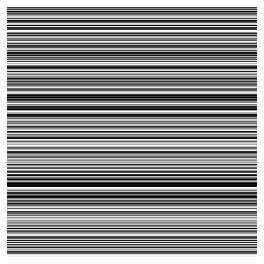

In [179]:
de_rle = decode_rle(en_rle, 250, 250)
plot_img_orig(de_rle)

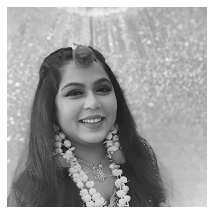

In [40]:
en_raida = cv2.imread('images/raida200200.png', 0)
plot_img_orig(en_raida)

In [41]:
en_rle_raida = encode_rle(en_raida)
en_rle_raida.size

70156

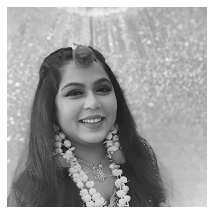

In [42]:
de_rle_raida = decode_rle(en_rle_raida, 200, 200)
plot_img_orig(de_rle_raida)

In [43]:
200*200

40000

In [41]:
# compress, decompress and analyze using rle (img = path to image)
def compress_decrompress_analyze_rle(img):
    # read the image as a grayscale image (parameter 0)
    img_in = cv2.imread(img, 0)
    rows, cols = img_in.shape
    
    print("Input image (" + str(rows) + " x " + str(cols) + " px, Type: " + str(img_in.dtype) + "):")
    plot_img_orig(img_in)
    
    # compute rle encoded representation
    img_rle = encode_rle(img_in)
    #np.set_printoptions(threshold=np.inf)
    #print(img_rle)
    print("RLE Type: " + str(img_rle.dtype))

    # decode data
    img_decoded = decode_rle(img_rle, rows, cols)
    print("Decoded image:");
    plot_img_orig(img_decoded)
    #print(img_decoded)

    # print number of bytes/ in this case, total number of pixels, i.e. 250x250
    print("Number of bytes input: " + str(img_in.nbytes))

    # print number of bytes
    print("Number of bytes compressed: " + str(img_rle.nbytes))

    # compute the compression ratio and relative data redundancy
    cr = img_in.nbytes / img_rle.nbytes
    rdr = 1-(1/cr)
    print("Compression ratio: " + str(cr))
    print("Relative data redundancy: " + str(rdr))

Input image (250 x 250 px, Type: uint8):


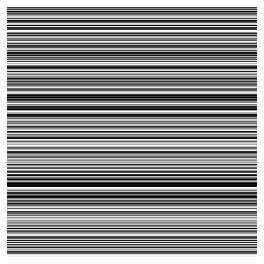

RLE Type: uint8
Decoded image:


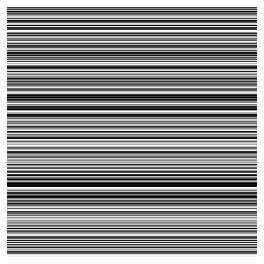

Number of bytes input: 62500
Number of bytes compressed: 500
Compression ratio: 125.0
Relative data redundancy: 0.992


In [42]:
# test of different images
compress_decrompress_analyze_rle('images/stripes.png')

Input image (250 x 250 px, Type: uint8):


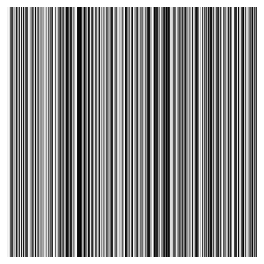

RLE Type: uint8
Decoded image:


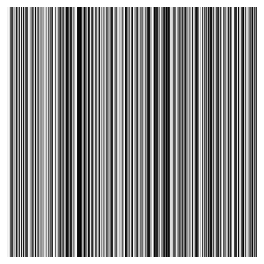

Number of bytes input: 62500
Number of bytes compressed: 125000
Compression ratio: 0.5
Relative data redundancy: -1.0
Input image (250 x 250 px, Type: uint8):


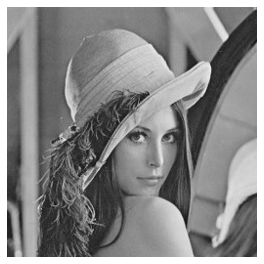

RLE Type: uint8
Decoded image:


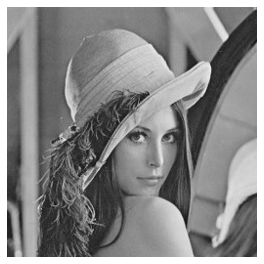

Number of bytes input: 62500
Number of bytes compressed: 113160
Compression ratio: 0.5523153057617533
Relative data redundancy: -0.8105600000000002
Input image (110 x 250 px, Type: uint8):


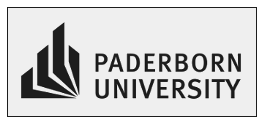

RLE Type: uint8
Decoded image:


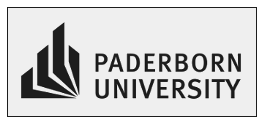

Number of bytes input: 27500
Number of bytes compressed: 9800
Compression ratio: 2.806122448979592
Relative data redundancy: 0.6436363636363637
Input image (200 x 200 px, Type: uint8):


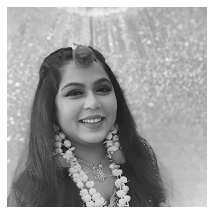

RLE Type: uint8
Decoded image:


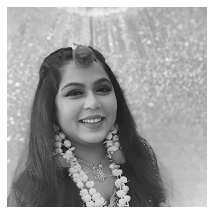

Number of bytes input: 40000
Number of bytes compressed: 70156
Compression ratio: 0.5701579337476481
Relative data redundancy: -0.7539


In [44]:
compress_decrompress_analyze_rle('images/stripes-vertical.png')
compress_decrompress_analyze_rle('images/lena-250x250.png')
compress_decrompress_analyze_rle('images/upb-logo.png')
compress_decrompress_analyze_rle('images/raida200200.png')

In [45]:
# secret image - can you decode and plot it?
import secret_image as si

print("\n" + "Secret image:") # \n is a new line
print("rows: " + str(si.rows))
print("cols: " + str(si.cols))
#np.set_printoptions(threshold=100)
print("RLE representation: " + str(si.img_rle))


Secret image:
rows: 250
cols: 250
RLE representation: [136 128  14 ...   5 136  88]


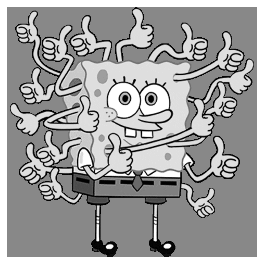

In [49]:
de_rle_si = decode_rle(si.img_rle, 250, 250)
plot_img_orig(de_rle_si)

#### <span style="color: RoyalBlue; font-weight: bold;">Task 14.2</span> Bit-Plane Coding with Gray Code

The principal idea of bit-plane coding is to decompose an image into a series of binary images and then use specific binary compression methods. One drawback is that adjacent numbers (intensity values) can lead to very different bit planes (e.g., $127_{10} = 01111111_2$ and $128_{10} = 10000000$, which means that all bit planes are changed, although the numbers are so close together). This can lead to complex bit-plane representations of actually connected pixels. The encoding becomes more easy if adjacent numbers (intensity values) are only differing by one bit. This can be achieved by using gray code.

For an 8 bit binary number $a_7 a_6 a_5 a_4 a_3 a_2 a_1 a_0$ ($a_0$ is the least significant bit), the corresponding gray code $g_7 g_6 g_5 g_4 g_3 g_2 g_1 g_0$ can be computed as follows ($\oplus$ means XOR):

$$g_i = a_i \oplus a_{i+1}$$
$$g_7 = a_7$$

Note that the result for $g_7$ corresponds to $g_7 = a_7 \oplus a_8$ with $a_8 = 0$. Based on the gray code, the corresponding binary representation can be computed using successive XOR operations:

$$a_7 = g_7$$
$$a_6 = g_7 \oplus g_6$$
$$a_5 = g_7 \oplus g_6 \oplus g_5$$
$$\cdots$$
$$a_0 = g_7 \oplus g_6 \oplus g_5 \oplus \cdots \oplus g_0$$

Implement / solve the following tasks:
    
1. Compute and plot the bit-plane which corresponds to $a_5$ for the image *lena-250x250.png*.
2. Compute and plot the gray code plane which corresponds to $g_5$.
3. Save both planes as PNG images.
4. Compute the compression ratio and relative data redundancy between the files and compare the results. Functions to compute the file size are already provided for convenience.

Input image:


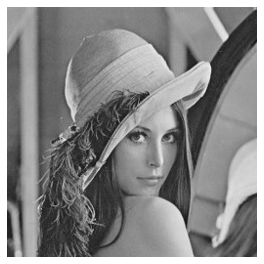

In [50]:
# read the image as a grayscale image (parameter 0)
img = cv2.imread('images/lena-250x250.png', 0)
print("Input image:")
plot_img_orig(img)

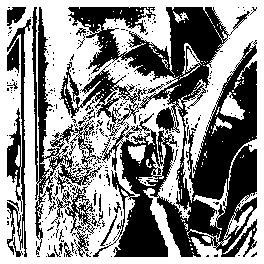

In [52]:
# compute and plot bit plane a_5 (also see task sheet 4)
img_ones = np.ones(shape=img.shape, dtype=np.uint8)
a_5 = cv2.bitwise_and(img >> 5, img_ones)
plot_img_orig(a_5*255)

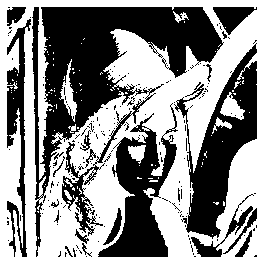

In [55]:
a_6 = cv2.bitwise_and(img >> 6, img_ones)
g_5 = cv2.bitwise_xor(a_6, a_5)
plot_img_orig(g_5*255)

In [56]:
cv2.imwrite('output/a_5.png', 255*a_5) #binary image, 255 or 0 pixel values
cv2.imwrite('output/g_5.png', 255*g_5)

True

In [57]:
# compare the file sizes
import os
a_5_size = os.stat('output/a_5.png')
g_5_size = os.stat('output/g_5.png')

print("a_5.png: ", a_5_size.st_size, "bytes")
print("g_5.png: ", g_5_size.st_size, "bytes")

a_5.png:  9531 bytes
g_5.png:  7050 bytes


In [58]:
cr = a_5_size.st_size / g_5_size.st_size
rdr = 1-(1/cr)
print("Compression ratio: " + str(cr))
print("Relative data redundancy: " + str(rdr))

Compression ratio: 1.3519148936170213
Relative data redundancy: 0.260308467107334


#### <span style="color: RoyalBlue; font-weight: bold;">Task 14.3</span> Lempel-Ziv-Welch (LZW) Coding 

LZW coding is a popular losless compression method to remove coding redundancy *and* interpixel redundancy. For this purpose, the method assigns fixed-length code words to variable length sequences of source symbols. An advantage of this method is that it requires no a priori knowledge of the probability of occurrence of the symbols to be encoded, because it encodes the data while processing it.

The idea of the method is simple yet powerful: reoccurring sequences are systematically added to a dictionary so that specific sequences are stored by one entry. It is therefore more efficient to store the position in the dictionary instead of the complete sequence. This leads to a compression. Of course, the dictionary has to be known to decode the compressed representation.

The following figure illustrates the method:
<br />
<center><img src="images/lzw.png"  width="400px" /></center>
<br />

Implement / solve the following tasks:
    
1. Write a function to reproduce the example from the table and print the dictionary and the code.
2. Based on this function, compute the dictionary and the code for the image *upb-logo.png* using 1D string representations (e.g., "42|255|12").
3. Compare the number of pixels of the input image and the size of the code (number of entries).
4. Compute the corresponding compression ratio and relative data redundancy and compare the results (number of pixels vs. size of the code).

In [3]:
# write your code here

# initial dictionary of unique characters. (not actual dictionary, just a list or 1d array)
dict = np.array(['a', 'b', 'c', 'd'])

# create input string
input = np.array(['a','a', 'b', 'a','b', 'a','c', 'b', 'a', 'a', 'c', 'b', 'a', 'a', 'd', 'a', 'a', 'a'])

# empty code output
code = np.array([], dtype=np.uint8)

# check if passed seq(uence) is in dictionary and return index
def in_dict(seq):
    if seq in dict:
        return np.where(dict == seq)[0] # take 1st element [0] because result is tuple. **but its not necessary.
    else:
        return 0
####['a','a', 'b', 'a','b', 'a','c', 'b', 'a', 'a', 'c', 'b', 'a', 'a', 'd', 'a', 'a', 'a']
####['0','1', '2', '3','4', '5','6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17']
# process input
last_seq = input[0] #a
for i in range(1, input.size): #1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
    seq = last_seq + input[i] #aa + a = aaa
    # check if this sequence is not in the dictionary
    if in_dict(seq) == False: #aaa, false
        dict = np.append(dict, seq) #aaa
        code = np.append(code, in_dict(last_seq)) # index of #last_seq part of sequence, #aa, #5
        last_seq = input[i] #a
    else: # sequence has been found
        last_seq = seq #a
        
#    # just print last element, why?
#    if i == input.size-1: #17
#        code = np.append(code, in_dict(input[i]))
        
print("dict = " + str(dict))
print("code = " + str(code+1))

dict = ['a' 'b' 'c' 'd' 'aa' 'ab' 'ba' 'aba' 'ac' 'cb' 'baa' 'acb' 'baad' 'da'
 'aaa']
code = [ 1  1  2  6  1  3  7  9 11  4  5]


In [4]:
dict = np.array(['a', 'b', 'c', 'd'])
input = np.array(['a','a', 'b', 'a','b', 'a','c', 'b', 'a', 'a', 'c', 'b', 'a', 'a', 'd', 'a', 'a', 'a'])
code = np.array([], dtype=np.uint8)

def in_dict(seq):
    if seq in dict:
        return np.where(dict == seq)[0]
    else:
        return 0
last_seq = input[0]
for i in range(1, input.size):
    seq = last_seq + input[i]
    if in_dict(seq) == False:
        dict = np.append(dict, seq)
        code = np.append(code, in_dict(last_seq))
        last_seq = input[i]
    else:
        last_seq = seq
print("dict: ", dict)
print("code: ", code)



dict:  ['a' 'b' 'c' 'd' 'aa' 'ab' 'ba' 'aba' 'ac' 'cb' 'baa' 'acb' 'baad' 'da'
 'aaa']
code:  [ 0  0  1  5  0  2  6  8 10  3  4]


In [5]:
dict = np.array(['a', 'b', 'c', 'd'])
input = np.array(['a','a', 'b', 'a','b', 'a','c', 'b', 'a', 'a', 'c', 'b', 'a', 'a', 'd', 'a', 'a', 'a'])
code = np.array([], dtype=np.uint8)

def in_dict(seq):
    if seq in dict:
        return np.where(dict == seq)[0]
    else:
        return 0
last_seq = input[0]
for i in range(1, input.size):
    seq = last_seq + input[i]
    if in_dict(seq) == False:
        dict = np.append(dict, seq)
        code = np.append(code, in_dict(last_seq))
        last_seq= input[i]
    else:
        last_seq = seq

print("dict: ", dict)
print("code: ", code)


dict:  ['a' 'b' 'c' 'd' 'aa' 'ab' 'ba' 'aba' 'ac' 'cb' 'baa' 'acb' 'baad' 'da'
 'aaa']
code:  [ 0  0  1  5  0  2  6  8 10  3  4]


In [6]:
code

array([ 0,  0,  1,  5,  0,  2,  6,  8, 10,  3,  4], dtype=int64)

In [7]:
code1 = code
dict = np.array(['a', 'b', 'c', 'd'])
priorCodeword = dict[code1[0]]
output = dict[code1[0]]
x = 1
codeword = np.array([])

def in_dict(codeword):
    if codeword in dict:
        return np.where(dict == seq)[0]
    else:
        return 0

while(x < code1.size):
    codeword = code1[x]
    priorString = dict[code1[x-1]]
    if dict[codeword] in dict:
        dict = np.append(dict, priorString+dict[codeword][0])
        #print(dict[codeword])
        output = np.append(output, dict[codeword])
    else:
        dict = np.append(dict, priorString+priorString[0])
        output = np.append(output, priorString +priorString[0])
    x+=1
output

array(['a', 'a', 'b', 'ab', 'a', 'c', 'ba', 'ac', 'baa', 'd', 'aa'],
      dtype='<U3')

In [8]:
# | separated value: for pixel.
datas = np.array(['a'])
datas = [x.split('|') for x in datas]

In [9]:
datas

[['a']]

In [10]:
datas[0][0]

'a'

In [11]:
# write your code here

# initial dictionary (arange can not be used to get a string representation)
dict = np.array([], dtype=object)
for i in range(256):
    dict = np.append(dict, str(i))


def in_dict(seq):
    if seq in dict:
        return np.where(dict == seq)[0]
    else:
        return 0
            
# read the image as a grayscale image (parameter 0)
img = cv2.imread('images/raida200200.png', 0)
img_flat = img.copy().flatten()
 
# empty code output
code = np.array([], dtype=object)

# process input
last_seq = img_flat[0]
for i in tqdm(range(1, img_flat.size)):
    seq = str(last_seq) + "|" + str(img_flat[i])
    
    # check if this sequence is in the dictionary
    if in_dict(seq) == False:
        dict = np.append(dict, seq)
        code = np.append(code, in_dict(last_seq))
        last_seq = str(img_flat[i])
    else: # sequence has been found
        last_seq = seq
        
    # just print last element, needed for decoding
    if i == input.size-1:
        code = np.append(code, in_dict(input[i]))

# compare the number of pixels and the size of the dictionary.
#np.set_printoptions(threshold=np.inf)
print("dict = " + str(dict))
print("code = " + str(code))

100%|██████████| 39999/39999 [00:26<00:00, 1504.05it/s]

dict = ['0' '1' '2' ... '218|219|218' '218|215|217' '217|219|220']
code = [0 191 187 ... 20431 517 14244]


In [12]:
img_flat

array([192, 191, 187, ..., 219, 220, 221], dtype=uint8)

In [13]:
# comparison of pixels and code entries
print(img_flat.size)
print(dict.size)

40000
20807


In [14]:
# compute the compression ratio and relative data redundancy
cr = img_flat.size / code.size
rdr = 1-(1/cr)
print("Compression ratio: " + str(cr))
print("Relative data redundancy: " + str(rdr))

Compression ratio: 1.9462826002335538
Relative data redundancy: 0.48619999999999997


In [15]:
img_flat

array([192, 191, 187, ..., 219, 220, 221], dtype=uint8)

In [16]:
for i in range(256):
    dict = np.append(dict, str(i))
dict

array(['0', '1', '2', ..., '253', '254', '255'], dtype=object)

In [17]:
img_flat[0:20]

array([192, 191, 187, 184, 183, 183, 185, 185, 186, 184, 184, 184, 186,
       185, 184, 183, 184, 185, 186, 184], dtype=uint8)

In [18]:
dict[256:276]

array(['192|191', '191|187', '187|184', '184|183', '183|183', '183|185',
       '185|185', '185|186', '186|184', '184|184', '184|184|186',
       '186|185', '185|184', '184|183|184', '184|185', '185|186|184',
       '184|184|187', '187|189', '189|188', '188|188'], dtype=object)

In [24]:
code[0:15]

array([0, 191, 187, 184, 183, 183, 185, 185, 186, 184, 265, 186, 185, 259,
       184], dtype=object)

In [31]:
code1 = code
dict = np.array([], dtype=object)

for i in range(256):
    dict = np.append(dict, str(i))

output = dict[code1[0]]
x = 1
codeword = np.array([])


def in_dict(seq):
    if seq in dict:
        return np.where(dict == seq)[0]
    else:
        return 0

def c_dict(codeword):
    if str(codeword) in dict:
        return True
    else:
        return False

while(x < code1.size):
    codeword = code1[x]
    priorString = dict[code1[x-1]]
    #if dict[codeword] in dict:
    if c_dict(codeword) == True:
        datas = [x.split('|') for x in np.array([dict[codeword]])]
        dict = np.append(dict, priorString+'|'+datas[0][0])
        output = np.append(output, dict[codeword])
    else:
        datas = [x.split('|') for x in np.array([priorString])] 
        dict = np.append(dict, priorString+ '|' +datas[0][0])
        output = np.append(output, priorString+ '|' +str(datas[0][0]))
    x+=1
    print('px: \r',x)

 2: 
 3: 
 4: 
 5: 
 6: 
 7: 
 8: 
 9: 
 10 
 11 
 12 
 13 
 14 
 15 
 16 
 17 
 18 
 19 
 20 
 21 
 22 
 23 
 24 
 25 
 26 
 27 
 28 
 29 
 30 
 31 
 32 
 33 
 34 
 35 
 36 
 37 
 38 
 39 
 40 
 41 
 42 
 43 
 44 
 45 
 46 
 47 
 48 
 49 
 50 
 51 
 52 
 53 
 54 
 55 
 56 
 57 
 58 
 59 
 60 
 61 
 62 
 63 
 64 
 65 
 66 
 67 
 68 
 69 
 70 
 71 
 72 
 73 
 74 
 75 
 76 
 77 
 78 
 79 
 80 
 81 
 82 
 83 
 84 
 85 
 86 
 87 
 88 
 89 
 90 
 91 
 92 
 93 
 94 
 95 
 96 
 97 
 98 
 99 
 100
 101
 102
 103
 104
 105
 106
 107
 108
 109
 110
 111
 112
 113
 114
 115
 116
 117
 118
 119
 120
 121
 122
 123
 124
 125
 126
 127
 128
 129
 130
 131
 132
 133
 134
 135
 136
 137
 138
 139
 140
 141
 142
 143
 144
 145
 146
 147
 148
 149
 150
 151
 152
 153
 154
 155
 156
 157
 158
 159
 160
 161
 162
 163
 164
 165
 166
 167
 168
 169
 170
 171
 172
 173
 174
 175
 176
 177
 178
 179
 180
 181
 182
 183
 184
 185
 186
 187
 188
 189
 190
 191
 192
 193
 194
 195
 196
 197
 198
 199
 200
 201


In [32]:
output[:15]

array(['0', '191', '187', '184', '183', '183', '185', '185', '186', '184',
       '184|184', '186', '185', '185|185', '184'], dtype='<U43')

In [33]:
img_flat[:15]

array([192, 191, 187, 184, 183, 183, 185, 185, 186, 184, 184, 184, 186,
       185, 184], dtype=uint8)

In [34]:
dict[256:280]

array(['0|191', '191|187', '187|184', '184|183', '183|183', '183|185',
       '185|185', '185|186', '186|184', '184|184', '184|184|186',
       '186|185', '185|185', '184|183|184', '184|0', '0|0', '185|186|185',
       '184|184|187', '187|189', '189|188', '188|188', '189|188|188',
       '188|190', '190|190'], dtype=object)

In [173]:
img_flat[0:25]

array([192, 191, 187, 184, 183, 183, 185, 185, 186, 184, 184, 184, 186,
       185, 184, 183, 184, 185, 186, 184, 184, 187, 189, 188, 188],
      dtype=uint8)

In [40]:
dict[4000]

'190|193|199|190'

In [46]:
'192' + '195'

'192195'

In [146]:
dict

array(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12',
       '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23',
       '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34',
       '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45',
       '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56',
       '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67',
       '68', '69', '70', '71', '72', '73', '74', '75', '76', '77', '78',
       '79', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89',
       '90', '91', '92', '93', '94', '95', '96', '97', '98', '99', '100',
       '101', '102', '103', '104', '105', '106', '107', '108', '109',
       '110', '111', '112', '113', '114', '115', '116', '117', '118',
       '119', '120', '121', '122', '123', '124', '125', '126', '127',
       '128', '129', '130', '131', '132', '133', '134', '135', '136',
       '137', '138', '139', '140', '141', '142', '143', '144

In [147]:
codeword

191

In [149]:
if str(codeword) in dict:
    print('hi')

hi


In [5]:
datas = [x.split('|') for x in np.array([priorString])]
datas[0][0]


NameError: name 'priorString' is not defined

In [37]:
if '255' in dict:
    print('hi')

hi


In [42]:
np.where(dict=='184|183')

(array([259], dtype=int64),)